# Assignment Experiment

In [ ]:
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *
%reload_ext autoreload
%autoreload 2
import helpers, helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment

**Goal: compare Local vs Global vs Hungarian assigments algorithms.**  
To this aim, we use the following params: 

In [ ]:
D = [0,1,2,3,4]
F = 30
N = 20

In [ ]:
frames, trajectories_GT, D_GT = generate_frames_OOP(F, N, amp = 1000, noise_gaussian = True, noise_poisson = True)

Frame 0


In [ ]:
print(D_GT)

[3, 3, 3, 1, 0]


In [ ]:
view_frames(frames)

In [ ]:
check_min_max(frames[2])

min: -36.571922045707396
max: 798.236722558933


In [ ]:
trajectories_detection, trajectories_localization = compute_d_l_trajectories(frames, trajectories_GT, D_GT)

Fitted center for peak at (11, 90): (10.69, 90.25), amplitude 1507.47, sigma 0.43
Fitted center for peak at (33, 108): (33.40, 108.06), amplitude 1559.22, sigma 0.51
Fitted center for peak at (92, 51): (91.78, 50.77), amplitude 1590.88, sigma 0.51
Fitted center for peak at (33, 108): (33.41, 108.07), amplitude 1618.88, sigma 0.50
Fitted center for peak at (89, 49): (89.43, 48.91), amplitude 1572.69, sigma 0.49
Fitted center for peak at (20, 93): (20.40, 92.82), amplitude 1557.70, sigma 0.50
Fitted center for peak at (14, 88): (14.41, 88.46), amplitude 1474.45, sigma 0.47
Fitted center for peak at (87, 47): (87.30, 46.76), amplitude 1594.34, sigma 0.48
Fitted center for peak at (17, 89): (17.28, 88.53), amplitude 822.56, sigma 0.46
Fitted center for peak at (86, 44): (86.03, 44.11), amplitude 1575.43, sigma 0.51
Fitted center for peak at (20, 90): (21.42, 92.53), amplitude 2860.00, sigma 0.30
Fitted center for peak at (33, 108): (33.44, 108.13), amplitude 1538.31, sigma 0.50
Fitted cent

In [ ]:
print(len(trajectories_detection), len(trajectories_localization))

5 2


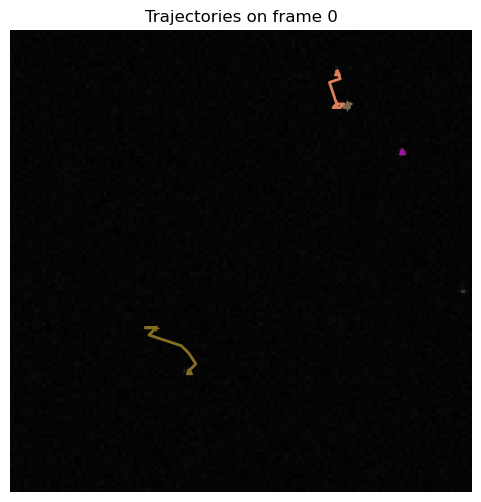

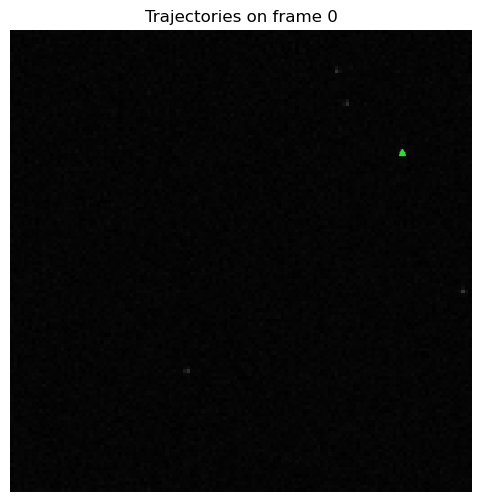

In [ ]:
show_trajectories(frames, trajectories_detection)
show_trajectories(frames, trajectories_localization)


### 1. Local NN assignment

In [ ]:
# reassign trajectories using local nn assignment algorithm
trajectories_d_local, min_cost_d_local, assignment_d_local = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='local_nn', verbose=True)
trajectories_l_local, min_cost_l_local, assignment_l_local = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='local_nn', verbose=True)

Cost matrix:
[[67.0121258   8.52134564 82.91423708 61.38929542 42.11423803]
 [ 2.50593269 72.53729213 82.06583761  3.15193814 23.90931327]
 [ 6.36268218 68.78753271 81.73985223  1.62760793 19.93943381]
 [83.97289128 83.36078489  1.22002656 81.21800563 83.39741934]
 [25.88819265 50.91725043 83.23934553 20.71146332  0.43798555]]
Computing assignment using algorithm: local_nn
0 -> 1
1 -> 0
2 -> 3
3 -> 2
4 -> 4
Trajectory ID: 1, Number of positions: 1, Relabelled: Yes
Trajectory ID: 0, Number of positions: 10, Relabelled: Yes
Trajectory ID: 3, Number of positions: 5, Relabelled: Yes
Trajectory ID: 2, Number of positions: 10, Relabelled: Yes
Trajectory ID: 4, Number of positions: 10, Relabelled: Yes
Total trajectories: 5, Relabelled trajectories: 1
Cost matrix:
[[5.07496249e+00 7.86361791e+01 8.81317997e+01 1.00073646e+01
  2.89066034e+01]
 [2.62113950e+01 5.05164928e+01 8.30387704e+01 2.10087882e+01
  3.63280969e-02]]
Computing assignment using algorithm: local_nn
0 -> 0
1 -> 4
Trajectory 

### 2. Global NN assignment

In [ ]:
# reassign trajectories using global nn assignment algorithm
trajectories_d_global, min_cost_d_global, assignment_d_global = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='global_nn')
trajectories_l_global, min_cost_l_global, assignment_l_global = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='global_nn')

### 3. Hungarian assignment

In [ ]:
# reassign trajectories using hungarian assignment algorithm
trajectories_d_hungarian, min_cost_d_hungarian, assignment_d_hungarian = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian', verbose=True)
trajectories_l_hungarian, min_cost_l_hungarian, assignment_l_hungarian = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian')

Cost matrix:
[[67.0121258   8.52134564 82.91423708 61.38929542 42.11423803]
 [ 2.50593269 72.53729213 82.06583761  3.15193814 23.90931327]
 [ 6.36268218 68.78753271 81.73985223  1.62760793 19.93943381]
 [83.97289128 83.36078489  1.22002656 81.21800563 83.39741934]
 [25.88819265 50.91725043 83.23934553 20.71146332  0.43798555]]
Computing assignment using algorithm: hungarian
0 -> 1
1 -> 0
2 -> 3
3 -> 2
4 -> 4
Trajectory ID: 1, Number of positions: 1, Relabelled: Yes
Trajectory ID: 0, Number of positions: 10, Relabelled: Yes
Trajectory ID: 3, Number of positions: 5, Relabelled: Yes
Trajectory ID: 2, Number of positions: 10, Relabelled: Yes
Trajectory ID: 4, Number of positions: 10, Relabelled: Yes
Total trajectories: 5, Relabelled trajectories: 1


In [ ]:
print_assignment(assignment_d_hungarian)
print_assignment(assignment_l_hungarian)

0 -> 1
1 -> 0
2 -> 3
3 -> 2
4 -> 4
0 -> 0
1 -> 4


### 4. Comparison -> minimum cost

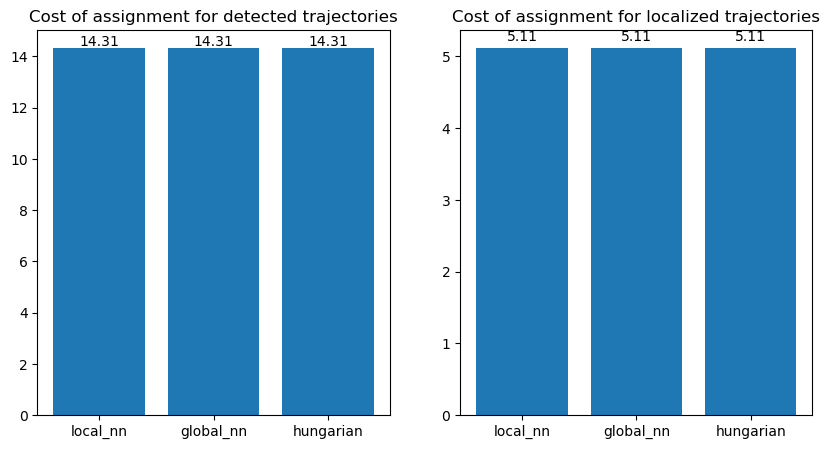

In [ ]:
# plot comparison of the algrorithms based on the cost of the assignment
algorithms = ['local_nn', 'global_nn', 'hungarian']
costs_d = [min_cost_d_local, min_cost_d_global, min_cost_d_hungarian]
costs_l = [min_cost_l_local, min_cost_l_global, min_cost_l_hungarian]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(algorithms, costs_d)
plt.title('Cost of assignment for detected trajectories')
for i, cost in enumerate(costs_d):
    plt.text(i, cost + 0.1, f'{cost:.2f}', ha='center')
plt.subplot(1,2,2)
plt.bar(algorithms, costs_l)
plt.title('Cost of assignment for localized trajectories')
for i, cost in enumerate(costs_l):
    plt.text(i, cost + 0.1, f'{cost:.2f}', ha='center')
plt.show()

-> cost for dists between found and?? GT??